# Домашнє завдання №11: причинно-наслідковий аналіз продуктової функції

**Студент:** Пилипенко  
**Дисципліна:** Продуктова аналітика та прикладна статистика

## Мета

Оцінити зв’язок між доступом до персоналізованих рекомендацій та утриманням користувачів, а також перевірити, чи можна інтерпретувати цей зв’язок як причинний.

У ноутбуці послідовно виконано:

1. кореляційний аналіз;
2. RCT/A/B-оцінку з Welch t-тестом і 95% довірчими інтервалами;
3. Propensity Score Matching (PSM) за `Avg_Session_Time` та `Region`;
4. перевірку overlap і балансу коваріат до та після matching;
5. підсумкову продуктову інтерпретацію та опис обмежень.

> `Group = Test` означає доступ до нової функції, `Group = Control` — відсутність доступу. Для бінарної retention-метрики середнє дорівнює частці утриманих користувачів.

## 0. Налаштування та імпорт бібліотек

Для відтворення аналізу потрібні `pandas`, `numpy`, `scipy`, `scikit-learn`, `matplotlib` і `seaborn`. Фіксуємо `RANDOM_STATE`, хоча основні розрахунки детерміновані.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import linear_sum_assignment
from scipy.special import logit
from scipy.stats import pearsonr, ttest_ind, ttest_rel, norm
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

ALPHA = 0.05
RANDOM_STATE = 42

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Завантаження та перевірка даних

Код підтримує запуск як із папки ноутбука, так і з кореня проєкту.

In [2]:
data_candidates = [
    Path("PA_assignment_11_data.csv"),
    Path("PA_assignment_11") / "PA_assignment_11_data.csv",
]
data_path = next((p for p in data_candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "Не знайдено PA_assignment_11_data.csv. "
        "Покладіть CSV поруч із ноутбуком або в папку PA_assignment_11."
    )

df = pd.read_csv(data_path)
print(f"Файл: {data_path.resolve()}")
print(f"Розмір: {df.shape[0]} рядків × {df.shape[1]} стовпців")
display(df.head())

Файл: C:\Study\AI_agent_LLM\PA_assignment_11\PA_assignment_11_data.csv
Розмір: 2000 рядків × 6 стовпців


,User_ID,Group,Retention_7d,Retention_30d,Avg_Session_Time,Region
0,101,Test,0,1,7,EU
1,102,Control,1,0,13,US
2,103,Test,1,0,9,US
3,104,Test,1,0,12,EU
4,105,Test,1,1,11,EU


In [3]:
required_columns = {
    "User_ID", "Group", "Retention_7d", "Retention_30d",
    "Avg_Session_Time", "Region"
}
missing_columns = required_columns - set(df.columns)
assert not missing_columns, f"Відсутні стовпці: {sorted(missing_columns)}"
assert set(df["Group"].unique()) == {"Test", "Control"}
assert df["Retention_7d"].isin([0, 1]).all()
assert df["Retention_30d"].isin([0, 1]).all()

quality = pd.Series({
    "Кількість рядків": len(df),
    "Пропущені значення": int(df.isna().sum().sum()),
    "Повні дублікати": int(df.duplicated().sum()),
    "Дублікати User_ID": int(df["User_ID"].duplicated().sum()),
})
display(quality.to_frame("Значення"))

print("Розподіл за групами:")
display(df["Group"].value_counts().rename_axis("Group").to_frame("n"))
print("Розподіл за регіонами:")
display(df["Region"].value_counts().rename_axis("Region").to_frame("n"))

,Значення
Кількість рядків,2000
Пропущені значення,0
Повні дублікати,0
Дублікати User_ID,0


Розподіл за групами:


,n
Group,
Test,1016
Control,984


Розподіл за регіонами:


,n
Region,
EU,684
US,663
Asia,653


Пропусків і дублікатів немає, типи груп і значення retention валідні. Отже, додаткове очищення не потрібне. Додаємо бінарний індикатор впливу: `Treatment = 1` для Test та `0` для Control.

Retention_7d               Retention_30d                \
               count   mean    std         count   mean    std   
Group                                                            
Control          984 0.5173 0.5000           984 0.5112 0.5001   
Test            1016 0.5059 0.5002          1016 0.4646 0.4990   

        Avg_Session_Time                 
                   count    mean    std  
Group                                    
Control              984 12.1463 4.3887  
Test                1016 12.1604 4.3118

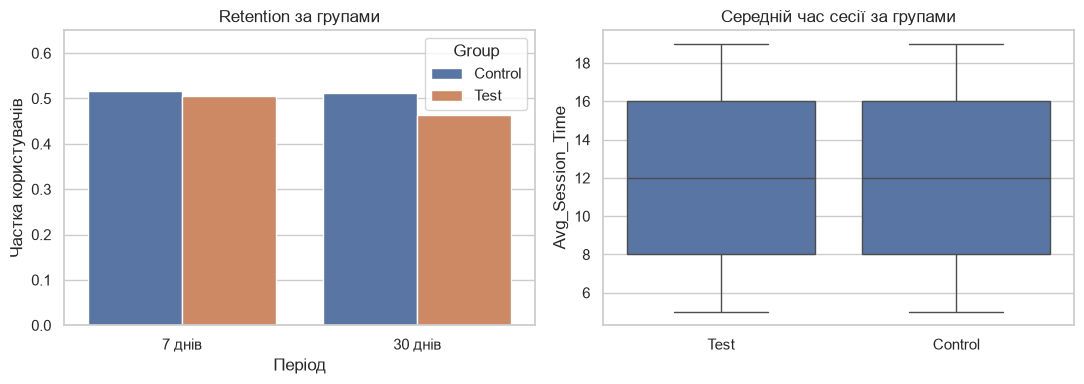

In [4]:
df = df.copy()
df["Treatment"] = (df["Group"] == "Test").astype(int)

summary = (
    df.groupby("Group")[["Retention_7d", "Retention_30d", "Avg_Session_Time"]]
      .agg(["count", "mean", "std"])
)
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
retention_means = (
    df.groupby("Group")[["Retention_7d", "Retention_30d"]]
      .mean()
      .rename(columns={"Retention_7d": "7 днів", "Retention_30d": "30 днів"})
      .reset_index()
      .melt(id_vars="Group", var_name="Період", value_name="Retention")
)
sns.barplot(data=retention_means, x="Період", y="Retention", hue="Group", ax=axes[0])
axes[0].set_title("Retention за групами")
axes[0].set_ylim(0, 0.65)
axes[0].set_ylabel("Частка користувачів")

sns.boxplot(data=df, x="Group", y="Avg_Session_Time", ax=axes[1])
axes[1].set_title("Середній час сесії за групами")
axes[1].set_xlabel("")
axes[1].set_ylabel("Avg_Session_Time")
plt.tight_layout()
plt.show()

## 2. Задача №1 — кореляція між функцією та retention

Оскільки і `Treatment`, і retention є бінарними змінними, Pearson correlation тут еквівалентна φ-коефіцієнту (і point-biserial correlation). Перевіряємо двосторонню гіпотезу $H_0: r=0$.

In [5]:
corr_rows = []
for metric in ["Retention_7d", "Retention_30d"]:
    r, p_value = pearsonr(df["Treatment"], df[metric])
    corr_rows.append({
        "Метрика": metric,
        "Кореляція r": r,
        "p-value": p_value,
        "Статистично значуща (α=0.05)": p_value < ALPHA,
    })

corr_results = pd.DataFrame(corr_rows).set_index("Метрика")
display(corr_results)

,Кореляція r,p-value,Статистично значуща (α=0.05)
Метрика,,,
Retention_7d,-0.0114,0.6112,False
Retention_30d,-0.0466,0.0371,True


In [6]:
for metric, row in corr_results.iterrows():
    direction = "позитивний" if row["Кореляція r"] > 0 else "негативний"
    significance = "статистично значущий" if row["p-value"] < ALPHA else "статистично незначущий"
    print(
        f"{metric}: r={row['Кореляція r']:.4f}, p={row['p-value']:.4f} — "
        f"{direction}, {significance} зв’язок."
    )

print(
    "\nВисновок: сама кореляція не доводить причинність. "
    "Для причинного висновку потрібні рандомізація або сильні ідентифікаційні припущення."
)

Retention_7d: r=-0.0114, p=0.6112 — негативний, статистично незначущий зв’язок.
Retention_30d: r=-0.0466, p=0.0371 — негативний, статистично значущий зв’язок.

Висновок: сама кореляція не доводить причинність. Для причинного висновку потрібні рандомізація або сильні ідентифікаційні припущення.


## 3. Задача №2 — оцінка впливу за допомогою RCT

### Гіпотези

Для кожної метрики:

- $H_0$: середній retention у Test і Control однаковий;
- $H_1$: середній retention відрізняється.

Використовуємо двосторонній Welch t-test (`equal_var=False`). Для бінарної змінної це тест різниці часток через різницю середніх; за великих груп він є коректною асимптотичною перевіркою. Додатково будуємо 95% CI для різниці `Test − Control`.

In [6]:
def independent_effect(data, metric, alpha=0.05):
    test = data.loc[data["Group"] == "Test", metric].astype(float)
    control = data.loc[data["Group"] == "Control", metric].astype(float)
    effect = test.mean() - control.mean()
    se = np.sqrt(test.var(ddof=1) / len(test) + control.var(ddof=1) / len(control))
    z_critical = norm.ppf(1 - alpha / 2)
    t_stat, p_value = ttest_ind(test, control, equal_var=False)
    return {
        "Метрика": metric,
        "n Test": len(test),
        "n Control": len(control),
        "Test mean": test.mean(),
        "Control mean": control.mean(),
        "Ефект Test−Control": effect,
        "Ефект, в.п.": 100 * effect,
        "95% CI нижня": effect - z_critical * se,
        "95% CI верхня": effect + z_critical * se,
        "t-statistic": t_stat,
        "p-value": p_value,
        "Значуща": p_value < alpha,
    }

rct_results = pd.DataFrame([
    independent_effect(df, "Retention_7d"),
    independent_effect(df, "Retention_30d"),
]).set_index("Метрика")
display(rct_results)

,n Test,n Control,Test mean,Control mean,Ефект Test−Control,"Ефект, в.п.",95% CI нижня,95% CI верхня,t-statistic,p-value,Значуща
Метрика,,,,,,,,,,,
Retention_7d,1016,984,0.5059,0.5173,-0.0114,-1.1371,-0.0552,0.0325,-0.5084,0.6112,False
Retention_30d,1016,984,0.4646,0.5112,-0.0466,-4.6612,-0.0904,-0.0028,-2.0861,0.0371,True


In [7]:
for metric, row in rct_results.iterrows():
    decision = "відхиляємо H₀" if row["p-value"] < ALPHA else "не відхиляємо H₀"
    print(
        f"{metric}: Test={row['Test mean']:.2%}, Control={row['Control mean']:.2%}, "
        f"ефект={row['Ефект, в.п.']:+.2f} в.п., "
        f"95% CI [{100*row['95% CI нижня']:+.2f}; {100*row['95% CI верхня']:+.2f}] в.п., "
        f"p={row['p-value']:.4f}; {decision}."
    )

print(
    "\nПричинна інтерпретація RCT є виправданою лише якщо Group справді призначено випадково, "
    "немає взаємного впливу між користувачами (SUTVA), вибіркового пропуску результатів "
    "та порушень експерименту."
)

Retention_7d: Test=50.59%, Control=51.73%, ефект=-1.14 в.п., 95% CI [-5.52; +3.25] в.п., p=0.6112; не відхиляємо H₀.
Retention_30d: Test=46.46%, Control=51.12%, ефект=-4.66 в.п., 95% CI [-9.04; -0.28] в.п., p=0.0371; відхиляємо H₀.

Причинна інтерпретація RCT є виправданою лише якщо Group справді призначено випадково, немає взаємного впливу між користувачами (SUTVA), вибіркового пропуску результатів та порушень експерименту.


## 4. Задача №3 — Propensity Score Matching (PSM)

PSM моделює ймовірність потрапляння в Test:

$$e(X_i)=P(T_i=1\mid X_i),$$

де $X_i$ містить `Avg_Session_Time` і `Region`.

Алгоритм:

1. стандартизуємо `Avg_Session_Time`, one-hot кодуємо `Region`;
2. оцінюємо propensity score логістичною регресією;
3. перевіряємо common support;
4. виконуємо 1:1 matching без повернення за відстанню між logit propensity score;
5. вимагаємо точний збіг за `Region` і застосовуємо caliper $0.2\,SD(\text{logit}(e(X)))$;
6. перевіряємо баланс коваріат через standardized mean difference (SMD).

Точний збіг за регіоном є додатковим обмеженням до matching за propensity score і гарантує регіональний баланс у зіставленій вибірці.

,count,min,mean,max,std
Group,,,,,
Control,984,0.4896,0.5070,0.5384,0.0215
Test,1016,0.4896,0.5089,0.5384,0.0220


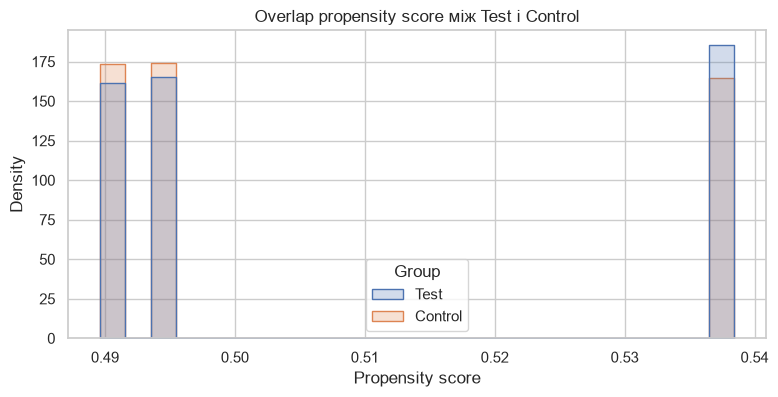

In [8]:
numeric_features = ["Avg_Session_Time"]
categorical_features = ["Region"]

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
    ]
)

ps_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(C=1e6, max_iter=2000, random_state=RANDOM_STATE)),
])

ps_model.fit(df[numeric_features + categorical_features], df["Treatment"])
df["Propensity_Score"] = ps_model.predict_proba(
    df[numeric_features + categorical_features]
)[:, 1]
df["Logit_PS"] = logit(df["Propensity_Score"].clip(1e-6, 1 - 1e-6))

display(
    df.groupby("Group")["Propensity_Score"]
      .agg(["count", "min", "mean", "max", "std"])
)

plt.figure(figsize=(9, 4))
sns.histplot(
    data=df, x="Propensity_Score", hue="Group", bins=25,
    stat="density", common_norm=False, element="step", fill=True, alpha=0.25
)
plt.title("Overlap propensity score між Test і Control")
plt.xlabel("Propensity score")
plt.show()

In [9]:
caliper = 0.2 * df["Logit_PS"].std(ddof=1)
pair_rows = []

for region in sorted(df["Region"].unique()):
    treated_idx = df.index[(df["Treatment"] == 1) & (df["Region"] == region)].to_numpy()
    control_idx = df.index[(df["Treatment"] == 0) & (df["Region"] == region)].to_numpy()

    # Угорський алгоритм мінімізує сумарну відстань для matching без повернення.
    cost = np.abs(
        df.loc[treated_idx, "Logit_PS"].to_numpy()[:, None]
        - df.loc[control_idx, "Logit_PS"].to_numpy()[None, :]
    )
    treated_pos, control_pos = linear_sum_assignment(cost)

    for t_pos, c_pos in zip(treated_pos, control_pos):
        distance = cost[t_pos, c_pos]
        if distance <= caliper:
            pair_rows.append({
                "Region": region,
                "treated_index": int(treated_idx[t_pos]),
                "control_index": int(control_idx[c_pos]),
                "distance": float(distance),
            })

pairs = pd.DataFrame(pair_rows)
assert not pairs.empty, "За заданим caliper не знайдено жодної пари."
assert pairs["treated_index"].is_unique and pairs["control_index"].is_unique

print(f"Caliper: {caliper:.4f}")
print(f"Зіставлено пар: {len(pairs)}")
print(f"Частка Test, що увійшла до matching: {len(pairs) / df['Treatment'].sum():.2%}")
print(f"Максимальна відстань у прийнятих парах: {pairs['distance'].max():.4f}")
display(pairs.groupby("Region").size().to_frame("Кількість пар"))

Caliper: 0.0174
Зіставлено пар: 964
Частка Test, що увійшла до matching: 94.88%
Максимальна відстань у прийнятих парах: 0.0018


,Кількість пар
Region,
Asia,320
EU,316
US,328


### 4.1. Перевірка балансу

Для числової або бінарної коваріати:

$$SMD=\frac{\bar X_T-\bar X_C}{\sqrt{(s_T^2+s_C^2)/2}}.$$

Орієнтир: $|SMD|<0.1$ зазвичай вважають добрим балансом.

,SMD до matching,SMD після matching
Коваріата,,
Avg_Session_Time,0.0032,0.0084
Region=Asia,-0.0500,0.0000
Region=EU,0.0866,0.0000
Region=US,-0.0374,0.0000


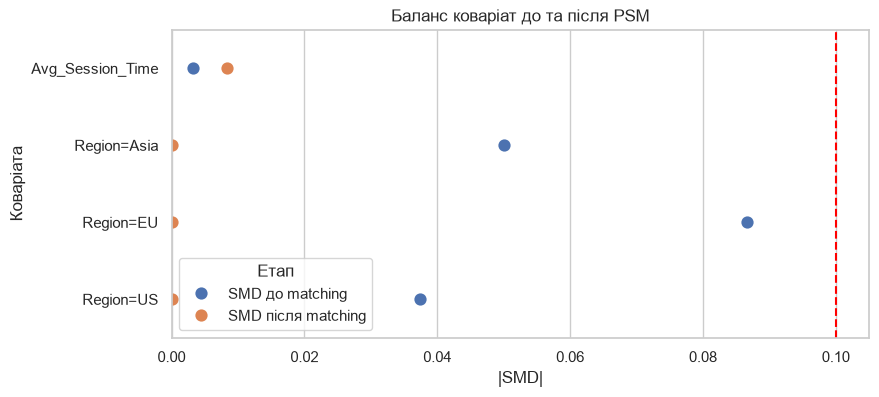

In [10]:
treated_before = df.loc[df["Treatment"] == 1]
control_before = df.loc[df["Treatment"] == 0]
treated_after = df.loc[pairs["treated_index"]].reset_index(drop=True)
control_after = df.loc[pairs["control_index"]].reset_index(drop=True)

def smd(x_t, x_c):
    x_t = np.asarray(x_t, dtype=float)
    x_c = np.asarray(x_c, dtype=float)
    pooled_sd = np.sqrt((np.var(x_t, ddof=1) + np.var(x_c, ddof=1)) / 2)
    if np.isclose(pooled_sd, 0):
        return 0.0
    return (np.mean(x_t) - np.mean(x_c)) / pooled_sd

balance_rows = [{
    "Коваріата": "Avg_Session_Time",
    "SMD до matching": smd(treated_before["Avg_Session_Time"], control_before["Avg_Session_Time"]),
    "SMD після matching": smd(treated_after["Avg_Session_Time"], control_after["Avg_Session_Time"]),
}]

for region in sorted(df["Region"].unique()):
    balance_rows.append({
        "Коваріата": f"Region={region}",
        "SMD до matching": smd(treated_before["Region"] == region, control_before["Region"] == region),
        "SMD після matching": smd(treated_after["Region"] == region, control_after["Region"] == region),
    })

balance = pd.DataFrame(balance_rows).set_index("Коваріата")
display(balance)

balance_plot = balance.abs().reset_index().melt(
    id_vars="Коваріата", var_name="Етап", value_name="|SMD|"
)
plt.figure(figsize=(9, 4))
sns.pointplot(
    data=balance_plot, y="Коваріата", x="|SMD|", hue="Етап",
    linestyle="none"
)
plt.axvline(0.1, color="red", linestyle="--", label="Поріг 0.1")
plt.title("Баланс коваріат до та після PSM")
plt.xlim(left=0)
plt.show()

### 4.2. Оцінка ATT після matching

Оскільки сформовано 1:1 пари, розраховуємо середню парну різницю Test − Control та застосовуємо парний t-тест. Це оцінка ATT для тієї частини Test-групи, що має відповідні Control-спостереження в межах common support і caliper.

In [11]:
def matched_effect(metric, alpha=0.05):
    y_t = treated_after[metric].to_numpy(dtype=float)
    y_c = control_after[metric].to_numpy(dtype=float)
    differences = y_t - y_c
    effect = differences.mean()
    se = differences.std(ddof=1) / np.sqrt(len(differences))
    z_critical = norm.ppf(1 - alpha / 2)
    t_stat, p_value = ttest_rel(y_t, y_c)
    return {
        "Метрика": metric,
        "Кількість пар": len(differences),
        "Test mean": y_t.mean(),
        "Matched Control mean": y_c.mean(),
        "ATT": effect,
        "ATT, в.п.": 100 * effect,
        "95% CI нижня": effect - z_critical * se,
        "95% CI верхня": effect + z_critical * se,
        "t-statistic": t_stat,
        "p-value": p_value,
        "Значуща": p_value < alpha,
    }

psm_results = pd.DataFrame([
    matched_effect("Retention_7d"),
    matched_effect("Retention_30d"),
]).set_index("Метрика")
display(psm_results)

comparison = pd.DataFrame({
    "RCT / повна вибірка, в.п.": rct_results["Ефект, в.п."],
    "PSM / matched ATT, в.п.": psm_results["ATT, в.п."],
    "RCT p-value": rct_results["p-value"],
    "PSM p-value": psm_results["p-value"],
})
display(comparison)

,Кількість пар,Test mean,Matched Control mean,ATT,"ATT, в.п.",95% CI нижня,95% CI верхня,t-statistic,p-value,Значуща
Метрика,,,,,,,,,,
Retention_7d,964,0.5031,0.5176,-0.0145,-1.4523,-0.0584,0.0294,-0.6483,0.5169,False
Retention_30d,964,0.4606,0.5124,-0.0519,-5.1867,-0.0961,-0.0076,-2.2968,0.0218,True


,"RCT / повна вибірка, в.п.","PSM / matched ATT, в.п.",RCT p-value,PSM p-value
Метрика,,,,
Retention_7d,-1.1371,-1.4523,0.6112,0.5169
Retention_30d,-4.6612,-5.1867,0.0371,0.0218


In [13]:
for metric, row in psm_results.iterrows():
    decision = "статистично значущий" if row["p-value"] < ALPHA else "статистично незначущий"
    print(
        f"{metric}: matched ATT={row['ATT, в.п.']:+.2f} в.п., "
        f"95% CI [{100*row['95% CI нижня']:+.2f}; {100*row['95% CI верхня']:+.2f}] в.п., "
        f"p={row['p-value']:.4f} — {decision}."
    )

Retention_7d: matched ATT=-1.45 в.п., 95% CI [-5.84; +2.94] в.п., p=0.5169 — статистично незначущий.
Retention_30d: matched ATT=-5.19 в.п., 95% CI [-9.61; -0.76] в.п., p=0.0218 — статистично значущий.


## 5. Підсумковий висновок

Нижче висновок формується безпосередньо з отриманих оцінок, щоб текст не розходився з результатами повторного запуску.

In [12]:
def describe_result(metric):
    rct = rct_results.loc[metric]
    psm = psm_results.loc[metric]
    rct_sig = rct["p-value"] < ALPHA
    psm_sig = psm["p-value"] < ALPHA
    direction = "зростання" if rct["Ефект Test−Control"] > 0 else "зниження"
    return (
        f"• {metric}: у повній вибірці спостерігається {direction} на "
        f"{abs(rct['Ефект, в.п.']):.2f} в.п. (p={rct['p-value']:.4f}; "
        f"{'значуще' if rct_sig else 'незначуще'}). Після PSM оцінка становить "
        f"{psm['ATT, в.п.']:+.2f} в.п. (p={psm['p-value']:.4f}; "
        f"{'значуще' if psm_sig else 'незначуще'})."
    )

print("РЕЗУЛЬТАТИ")
print(describe_result("Retention_7d"))
print(describe_result("Retention_30d"))

if (rct_results["Ефект Test−Control"] > 0).all() and (rct_results["p-value"] < ALPHA).all():
    recommendation = "Є підстави вважати, що функція покращує обидві retention-метрики."
else:
    recommendation = (
        "Дані не підтверджують твердження, що функція покращує retention. "
        "Не рекомендується повний rollout лише на підставі цього експерименту; "
        "варто перевірити реалізацію, сегменти та повторити тест після формування гіпотез."
    )
print(f"\nПРОДУКТОВА РЕКОМЕНДАЦІЯ\n{recommendation}")

РЕЗУЛЬТАТИ
• Retention_7d: у повній вибірці спостерігається зниження на 1.14 в.п. (p=0.6112; незначуще). Після PSM оцінка становить -1.45 в.п. (p=0.5169; незначуще).
• Retention_30d: у повній вибірці спостерігається зниження на 4.66 в.п. (p=0.0371; значуще). Після PSM оцінка становить -5.19 в.п. (p=0.0218; значуще).

ПРОДУКТОВА РЕКОМЕНДАЦІЯ
Дані не підтверджують твердження, що функція покращує retention. Не рекомендується повний rollout лише на підставі цього експерименту; варто перевірити реалізацію, сегменти та повторити тест після формування гіпотез.


### Інтерпретація та обмеження

- **Кореляція не є причинністю.** Вона лише описує напрям і силу статистичного зв’язку.
- **RCT — основна оцінка**, якщо розподіл між Test і Control справді був випадковим. Тоді різницю середніх можна інтерпретувати як середній причинний ефект за стандартних припущень експерименту.
- **PSM є аналізом чутливості**, а не сильнішою заміною коректного RCT. Він балансує тільки спостережувані змінні; приховані confounders залишаються можливими.
- Якщо `Avg_Session_Time` виміряно **після** активації функції, це потенційний медіатор, а не pre-treatment confounder. Matching за ним може вносити post-treatment bias. Ознаку використано, бо це прямо вимагає завдання, але для реального причинного аналізу потрібно уточнити момент її вимірювання.
- PSM-результат є **ATT для matched subset**, тому може не узагальнюватися на всіх користувачів.
- **IV не застосовано**, оскільки в наборі немає змінної-кандидата на інструмент, для якої можна обґрунтувати relevance та exclusion restriction.
- **DiD не застосовано**, оскільки немає outcome до/після запуску та неможливо перевірити припущення parallel trends. Вигадувати інструмент або pre-period було б методологічно некоректно.

Отже, рішення про масштабування слід базувати насамперед на RCT-оцінках, їхніх довірчих інтервалах, практичній величині ефекту та перевірці коректності експерименту.